<a href="https://colab.research.google.com/github/sarkarj2002/UCB-Assignment-5.1/blob/main/prompt_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

The business task of identifying key drivers for used car prices and understanding factors influencing their value can be reframed as a data problem involving predictive modeling and feature engineering. The objective is to develop a regression model that accurately predicts used car prices based on a set of independent variables (car features like make, model, year, mileage, condition, etc.) within the provided dataset. This involves data exploration to understand variable distributions and relationships, followed by feature selection and transformation to optimize model performance and interpretability.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.svm import SVR


In [21]:
veh=pd.read_csv('vehicles.csv')
veh.shape
#veh.info()
# Will keep only price, year, manufacturer,model,fuel,odometer,title_status,transmission in the dataframe
veh_col=['price', 'year', 'manufacturer','model','fuel','odometer','title_status','transmission']
veh_chg=veh[veh_col]
veh_chg.info()
veh_chg.shape
veh_chg['title_status'].unique()
veh_chg.describe()
veh_chg.tail(10)
veh_chg[veh_chg['year']==1900.0].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         426880 non-null  int64  
 1   year          425675 non-null  float64
 2   manufacturer  409234 non-null  object 
 3   model         421603 non-null  object 
 4   fuel          423867 non-null  object 
 5   odometer      422480 non-null  float64
 6   title_status  418638 non-null  object 
 7   transmission  424324 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 26.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 29955 to 398032
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         12 non-null     int64  
 1   year          12 non-null     float64
 2   manufacturer  5 non-null      object 
 3   model         12 non-null     object 
 4   fuel          12 no

In [57]:
yearly_avearge_miles_driven=veh_chg.groupby('year')['odometer'].mean()
yearly_avearge_miles_driven.sort_values(ascending=False)
Price_by_transmission_by_fuel=veh_chg.groupby(['transmission','fuel'])['price'].max()
Price_by_transmission_by_fuel.reset_index()


,transmission,fuel,price
0,automatic,diesel,1111111111
1,automatic,electric,130000
2,automatic,gas,3736928711
3,automatic,hybrid,109999
4,automatic,other,128995
5,manual,diesel,1410065407
6,manual,electric,79995
7,manual,gas,1111111
8,manual,hybrid,19990
9,manual,other,1234567890


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [26]:
veh_chg.isnull().sum()
veh_chg.dropna(inplace=True)
veh_chg.isnull().sum()
veh_chg.head(10)
veh_chg.info()


/tmp/ipython-input-2691726908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_chg.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         389604 non-null  int64  
 1   year          389604 non-null  float64
 2   manufacturer  389604 non-null  object 
 3   model         389604 non-null  object 
 4   fuel          389604 non-null  object 
 5   odometer      389604 non-null  float64
 6   title_status  389604 non-null  object 
 7   transmission  389604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 26.8+ MB


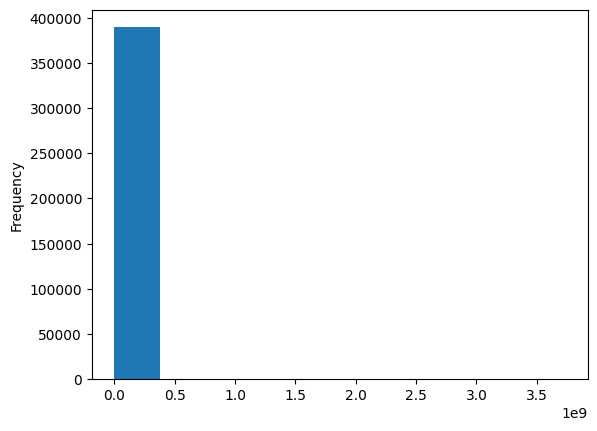

In [37]:
veh_chg.duplicated().sum() #No duplicate data
#veh_chg['price'].nunique()
veh_chg['price'].plot(kind='hist',bins=10)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

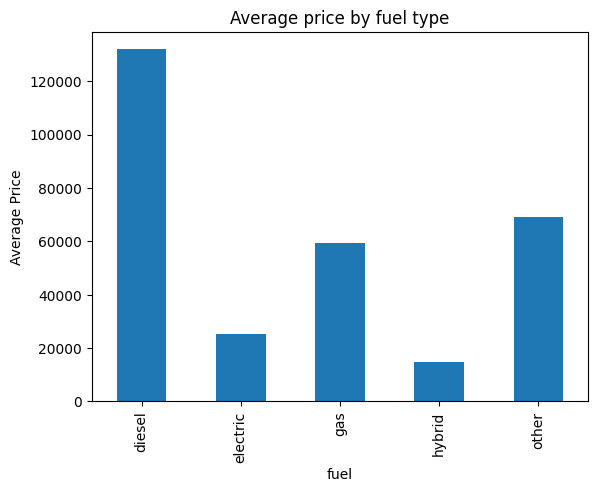

In [44]:
veh_price_fuel_type=veh_chg.groupby('fuel')['price'].mean()
veh_price_fuel_type.plot(kind='bar',title='Average price by fuel type')
plt.xlabel('fuel')
plt.ylabel('Average Price')
plt.show


<Axes: title={'center': 'Distribution of Transmission Type'}, ylabel='count'>

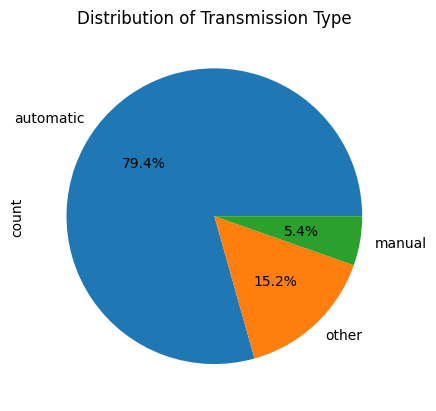

In [48]:
transmission_cnt=veh_chg['transmission'].value_counts()
transmission_cnt.plot(kind='pie',autopct='%1.1f%%',title='Distribution of Transmission Type')

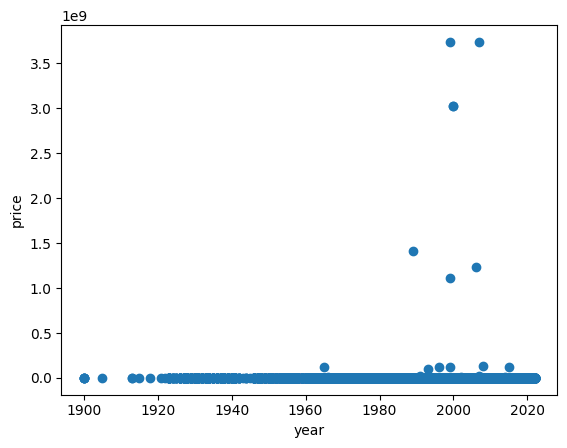

None


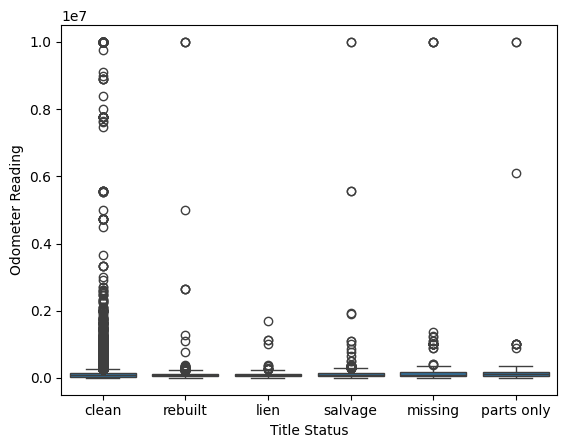

None


transmission,automatic,manual,other
fuel,,,
diesel,82055.786072,9.858321e+05,18553.657827
electric,22609.640316,1.483378e+04,28258.867758
gas,67070.139672,1.351398e+04,28145.900315
hybrid,12893.441831,1.714715e+04,22206.966559
other,20404.079531,4.862964e+06,29520.531419


In [64]:
plt.scatter(veh_chg['year'],veh_chg['price'])
plt.xlabel('year')
plt.ylabel('price')
print(plt.show())

sns.boxplot(x='title_status',y='odometer',data=veh_chg)
plt.xlabel('Title Status')
plt.ylabel('Odometer Reading')
print(plt.show())

#veh_chg.groupby(['fuel','transmission'])['price'].mean().unstack().plot(kind='bar',stacked=True)
veh_chg.groupby(['fuel','transmission'])['price'].mean().unstack()
#plt.xlabel('Fuel type')
#plt.ylabel('Average Price')
#print(plt.show())



### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [89]:
y=veh_chg['price']
X=veh_chg[['year','odometer','fuel','title_status','transmission']]
X.head()
labelencoder=preprocessing.LabelEncoder()
X['fuel']=labelencoder.fit_transform(X['fuel'])
X['transmission']=labelencoder.fit_transform(X['transmission'])
X['title_status']=labelencoder.fit_transform(X['title_status'])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
scaler=StandardScaler()
scaled_X_train=scaler.fit_transform(X_train)
scaled_X_test=scaler.fit_transform(X_test)






/tmp/ipython-input-2231689214.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['fuel']=labelencoder.fit_transform(X['fuel'])
/tmp/ipython-input-2231689214.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['transmission']=labelencoder.fit_transform(X['transmission'])
/tmp/ipython-input-2231689214.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

array([[-0.07038486,  0.36855827, -0.03598069, -0.17327298, -0.49051125],
       [-0.64996087,  0.05519961, -0.03598069, -0.17327298,  0.87679533],
       [ 0.04553035, -0.20025492, -0.03598069, -0.17327298, -0.49051125],
       ...,
       [-0.64996087,  0.38389013,  1.29623247, -0.17327298, -0.49051125],
       [-2.62051933, -0.29418737, -0.03598069, -0.17327298,  0.87679533],
       [ 0.16144555, -0.13217476, -0.03598069, -0.17327298, -0.49051125]])

In [93]:
def modelresults(predictions):
  print("Mean Absolute Error is {}".format(mean_absolute_error(y_test,predictions)))
  print("Root Mean Squared Error is {}".format(np.sqrt(mean_squared_error(y_test,predictions))))



In [94]:
lr=LinearRegression()
lr.fit(scaled_X_train,y_train)
predslr=lr.predict(scaled_X_test)
modelresults(predslr)

Mean Absolute Error is 81253.32726135991
Root Mean Squared Error is 4423451.719001568


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [98]:
from sklearn.model_selection import GridSearchCV

In [102]:
svrmodel=SVR()
param_gridsvr={'C':[.0001,.001,.01,.1,.5],'kernel':['linear','rbf','poly'],'degree':[2,3,4]}


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.